In [1]:
import shutup; shutup.please()
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
import os
import shutup; shutup.please()
import scanpy as sc
import pandas as pd
import os
from sklearn.mixture import GaussianMixture
import numpy as np
from kneed import KneeLocator
import matplotlib.pyplot as plt
import argparse
import time
from pybiomart import Dataset

# Set default figure size
plt.rcParams['figure.figsize'] = (12, 6)
PT_SIZE = 90
SAVE_MATRIX = True

In [3]:
def get_all_gene_aliases(gene_list, species="hsapiens"):
    """Retrieve all aliases for a list of genes using the Ensembl database.
    
    Args:
        gene_list (list): List of gene names to find aliases for.
        species (str): Species name for the Ensembl database (default is "hsapiens").

    Returns:
        set: A set of all aliases found for the given gene list.
    """
    # Create a dataset object for the specified species
    dataset = Dataset(name=f'{species}_gene_ensembl', host='http://www.ensembl.org')
    results = dataset.query(attributes=['ensembl_gene_id',
                                        'external_gene_name',
                                        'hgnc_symbol',
                                        'external_synonym'])
    # Set results as lowercase
    results_lower = results.applymap(lambda x: str(x).lower() if pd.notnull(x) else x)
    all_aliases = set()
    # Iterate over each gene in the input list to find its aliases
    for gene in gene_list:
        gene_lower = gene.lower()
        mask = results_lower.eq(gene_lower).any(axis=1)
        all_aliases |= set(results[mask].values.flatten().tolist())
    return all_aliases

def compute_optimal_components(data, n_range):
    """Compute the optimal number of components for a Gaussian Mixture Model using BIC.
    
    Args:
        data (np.ndarray): Input data for fitting the Gaussian Mixture Model.
        n_range (range): Range of number of components to test.

    Returns:
        tuple: A tuple containing the fitted Gaussian Mixture Model and the optimal number of components.
    """
    bics, models = [], []
    for n in n_range:
        gmm = GaussianMixture(n_components=n, n_init=10, reg_covar=1e-6)
        gmm.fit(data)
        bics.append(gmm.bic(data))
        models.append(gmm)

    knee_bic = KneeLocator(n_range, bics, curve='convex', direction='decreasing')
    optimal_n = knee_bic.knee

    return models[optimal_n-1], optimal_n

In [4]:
adata_zeng = sc.read_h5ad("/home/lemgui01/CellExtractor/data/results_mk_11/find/Zeng_biorxiv_2023_12_26_573390.h5ad")
adata_zeng.X = adata_zeng.layers["raw"]

sc.pp.normalize_total(adata_zeng, target_sum=1e6)
sc.pp.log1p(adata_zeng)

sc.tl.pca(adata_zeng, n_comps=20, svd_solver="arpack")
sc.pp.neighbors(adata_zeng, n_pcs=20)
sc.tl.umap(adata_zeng)

In [5]:
MK_genes = ["PPBP", "GP6", "PF4", "CD40LG", "FCGR2A", "GP1BA", "ITGB3", "ITGA2B"]
MK_aliases = get_all_gene_aliases(MK_genes, species="hsapiens")
MK_genes_avail = MK_aliases & set(adata_zeng.var_names)

MONO_genes = ["S100A8", "S100A9", "SERPINA1", "LYZ", "FCN1", "CTSS"] + ["CD14", "CD16", "CD115", "CD64", "CCR2", "CCR5", "CX3CR1", "CD86", "CD11c"]
MONO_aliases = get_all_gene_aliases(MONO_genes, species="hsapiens")
MONO_genes_avail = MONO_aliases & set(adata_zeng.var_names)

adata_subset_MK = adata_zeng[:, list(MK_genes_avail)]
mean_expr = adata_subset_MK.to_df().mean(axis=1)
adata_zeng.obs["MK_mean_expr"] = mean_expr

adata_subset_MONO = adata_zeng[:, list(MONO_genes_avail)]
mean_expr = adata_subset_MONO.to_df().mean(axis=1)
adata_zeng.obs["MONO_mean_expr"] = mean_expr

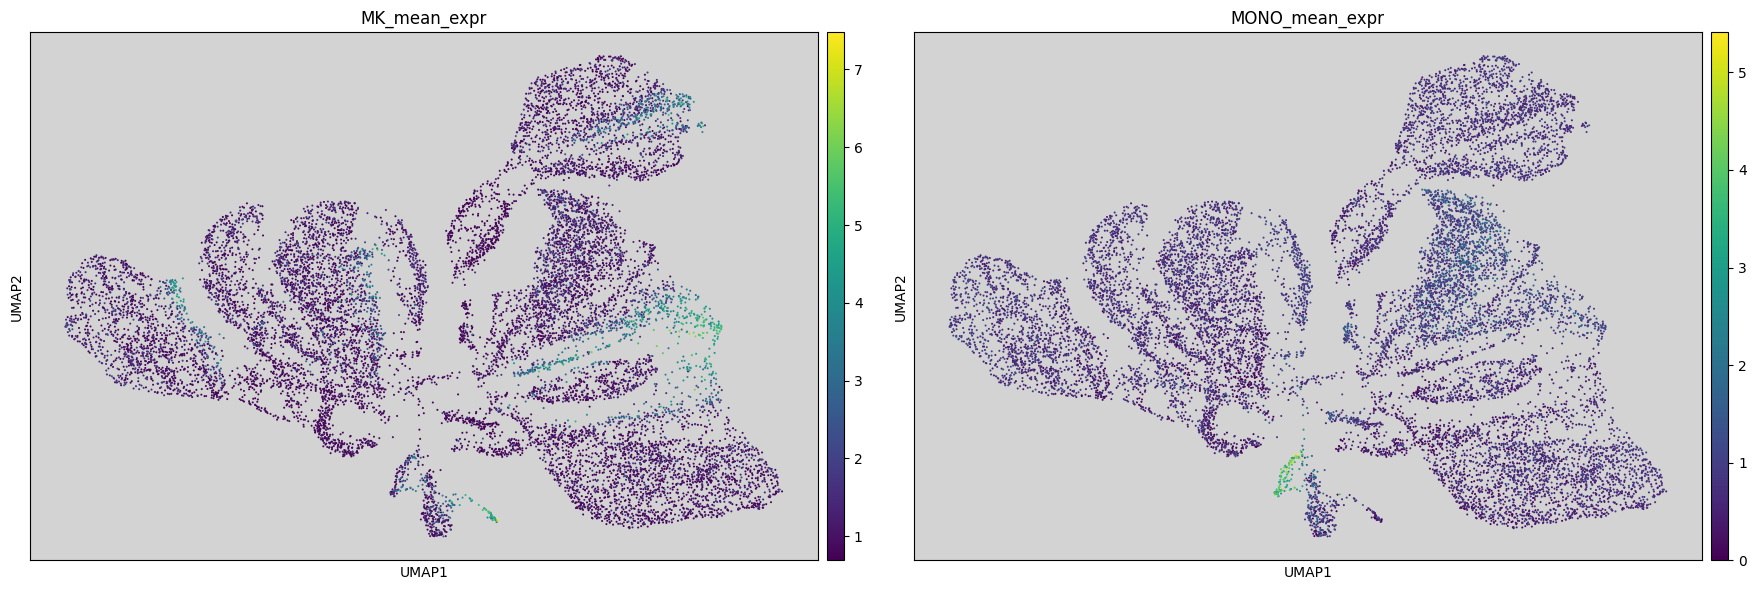

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(18, 6))
sc.pl.umap(adata_zeng, color="MK_mean_expr", cmap="viridis", ax=axs[0], show=False)
sc.pl.umap(adata_zeng, color="MONO_mean_expr", cmap="viridis", ax=axs[1], show=False)
axs[0].set_facecolor('lightgrey')
axs[1].set_facecolor('lightgrey')
plt.tight_layout()

In [7]:
n_components = "auto"
os.environ['OPENBLAS_NUM_THREADS'] = '60'

######## MK GMM ########
print("MK GMM")
data_mk = np.array(adata_zeng.obs['MK_mean_expr']).reshape(-1, 1)
if n_components == "auto":
    print("Automatically determining the number of components using BIC...")
    max_components = min(10, adata_zeng.shape[0])
    print(f"Testing up to {max_components} components...")
    gmm_mk, optimal_n = compute_optimal_components(data_mk, n_range=range(1, max_components))
    print(f"Optimal number of components: {optimal_n}")
else:
    print(f"Using specified number of components: {n_components}")
    gmm_mk = GaussianMixture(n_components=int(n_components), n_init=10, reg_covar=1e-6).fit(data_mk)
print("Fitting Gaussian Mixture Model...")
probas = gmm_mk.predict_proba(data_mk)
means = gmm_mk.means_.flatten()
target_component = np.argmax(means)

proba_target = probas[:, target_component]
adata_zeng.obs["proba_MK"] = proba_target

######## MONO GMM ########
print("-----------\nMONO GMM")
data_mono = np.array(adata_zeng.obs['MONO_mean_expr']).reshape(-1, 1)
if n_components == "auto":
    print("Automatically determining the number of components using BIC...")
    max_components = min(10, adata_zeng.shape[0])
    print(f"Testing up to {max_components} components...")
    gmm_mono, optimal_n = compute_optimal_components(data_mono, n_range=range(1, max_components))
    print(f"Optimal number of components: {optimal_n}")
else:
    print(f"Using specified number of components: {n_components}")
    gmm_mono = GaussianMixture(n_components=int(n_components), n_init=10, reg_covar=1e-6).fit(data_mono)
print("Fitting Gaussian Mixture Model...")
probas = gmm_mono.predict_proba(data_mono)
means = gmm_mono.means_.flatten()
target_component = np.argmax(means)

proba_target = probas[:, target_component]
adata_zeng.obs["proba_MONO"] = proba_target

MK GMM
Automatically determining the number of components using BIC...
Testing up to 10 components...


Optimal number of components: 3
Fitting Gaussian Mixture Model...
-----------
MONO GMM
Automatically determining the number of components using BIC...
Testing up to 10 components...
Optimal number of components: 5
Fitting Gaussian Mixture Model...


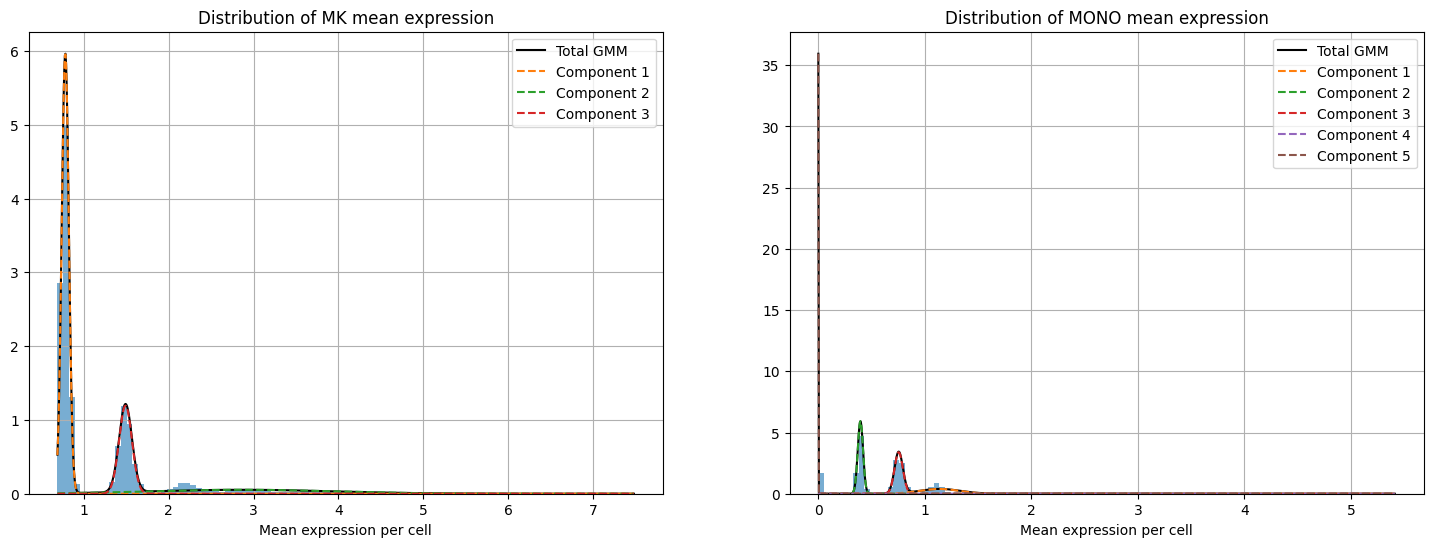

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

ax[0].hist(data_mk, bins=100, alpha=0.6, density=True)
ax[0].set(title="Distribution of MK mean expression", xlabel="Mean expression per cell")
ax[0].grid(True)

x = np.linspace(data_mk.min(), data_mk.max(), 1000).reshape(-1, 1)
pdf = np.exp(gmm_mk.score_samples(x))
pdf_individual = gmm_mk.predict_proba(x) * pdf[:, None]

ax[0].plot(x, pdf, '-k', label='Total GMM')
for i in range(gmm_mk.n_components):
    ax[0].plot(x, pdf_individual[:, i], '--', label=f'Component {i+1}')
ax[0].legend()
#####################
ax[1].hist(data_mono, bins=100, alpha=0.6, density=True)
ax[1].set(title="Distribution of MONO mean expression", xlabel="Mean expression per cell")
ax[1].grid(True)

x = np.linspace(data_mono.min(), data_mono.max(), 1000).reshape(-1, 1)
pdf = np.exp(gmm_mono.score_samples(x))
pdf_individual = gmm_mono.predict_proba(x) * pdf[:, None]

ax[1].plot(x, pdf, '-k', label='Total GMM')
for i in range(gmm_mono.n_components):
    ax[1].plot(x, pdf_individual[:, i], '--', label=f'Component {i+1}')
ax[1].legend()

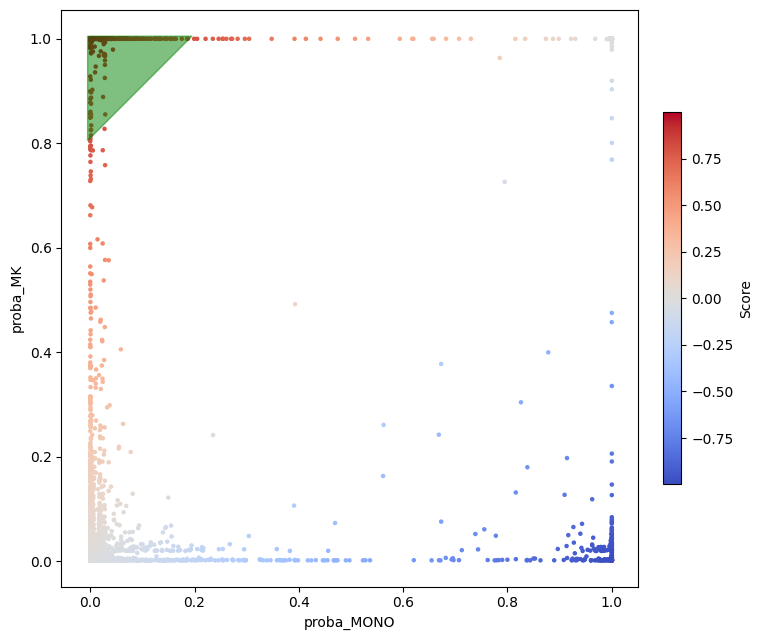

In [113]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

x = adata_zeng.obs['proba_MONO']
y = adata_zeng.obs['proba_MK']
score = y - x

score_thresh = 0.8

fig, ax = plt.subplots(figsize=(8, 8))

# scatter coloré par le score
sc = ax.scatter(x, y, c=score, cmap='coolwarm', s=5)

ray = 1-score_thresh
c = [-0.005,1.005]
triangle_coords = np.array([c, [c[0]+ray, c[1]] , [c[0], c[1]-ray]])
triangle = Polygon(triangle_coords, color='green', alpha=0.5)
ax.add_patch(triangle)

ax.set_box_aspect(1)
ax.set_xlabel('proba_MONO')
ax.set_ylabel('proba_MK')

# légendes et barre de couleur
cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Score')

plt.show()